In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


class ErrModelBase:
    """ Base class for error models in two-qubit RB."""
    name = "model"
    p1_name = "param1"
    p2_name = "param2"
    p3_name = "param3"
    p4_name = "param4"
    bounds = ([0.0, 0.0, 0.0, 0.0], [1.0, 1.0, 1.0, 1.0])
    p0 = [0, 0, 0, 0]

    def model(self, m, p):
        raise NotImplementedError("Subclasses must implement the model method.")

    def fit_model(self, P_SS, P_SF, P_FS, P_FF, m):
        P = np.concatenate([P_SS, P_SF, P_FS, P_FF])
        popt, pcov = curve_fit(self.model, m, P, p0=self.p0, bounds=self.bounds)
        return popt, pcov

    def generate_data(self, ms, p, n_shots):
        Pops = []
        for m in ms:
            P_true = self.decay_curves(m, p)
            P = []
            for P_ij_true in P_true:
                P_ij = np.random.binomial(n_shots, np.round(P_ij_true,5)) / n_shots
                P.append(P_ij)
            Pops.append(P)
        return np.array(Pops)

class SO3Model(ErrModelBase):
    """ Random small SO3 rotations mode for two-qubit RB. This is the model used in main text """
    name = "SO3"
    p1_name = "$\\varepsilon_\\mathrm{corr}$"
    p2_name = "$\\varepsilon_{L}$"
    p3_name = "$\\varepsilon_{R}$"
    p4_name = "SPAM"
    bounds = ([0.0, 0.0, 0.0, 0.0], [10.0, 10.0, 10.0, 0.1])
    p0 = [0.1, 0.01, 0.01, 0.01]

    def model(self, m, e_corr, e_L, e_R, spam):
        p = [e_corr, e_L, e_R, spam]
        P_SS, P_SF, P_FS, P_FF = self.decay_curves(m, p)
        return np.concatenate([P_SS, P_SF, P_FS, P_FF])

    def decay_curves(self, x, p):
        """
        Decay equation for two-qubit correlated populations after k-copy RB.
            m: sequence length
        """
        e_corr, e_L, e_R, spam = p
        atr = 1 - e_L - e_R
        adt = 1 - e_L - e_R - 3 * e_corr
        aL = 1 - e_L - e_corr
        aR = 1 - e_R - e_corr
        sp = 1 - 2 * spam
        S1 = sp * aL**x
        S2 = sp * aR**x
        M1 = 2 * sp**2 * adt**x / 3
        M2 = sp**2 * atr**x / 3
        P_SS = (1 + S1 + S2 + M1 + M2) / 4
        P_SF = (1 + S1 - S2 - M1 - M2) / 4
        P_FS = (1 - S1 + S2 - M1 - M2) / 4
        P_FF = (1 - S1 - S2 + M1 + M2) / 4

        return P_SS, P_SF, P_FS, P_FF


    def parity_model(self, x, e_corr, e_L_e_R):
        atr = 1 - e_L_e_R
        adt = 1 - e_L_e_R - 3 * e_corr
        return (1 / 3) * (atr**x - adt**x)

class corrDiffModel(ErrModelBase):
    """ corrmon/differential error model for two-qubit RB."""
    name = "single_qubit_err"
    p1_name = "corrmon Noise (e_corr)"
    p2_name = "Differential Noise (e_diff)"
    p3_name = "Imbalance angle (phi)"
    bounds = ([0.0, 0.0, 0.0], [10.0, 10.0, 2 * np.pi])
    p0 = [0.1, 0.1, np.pi]

    def model(self, m, e_corr, e_diff, phi):
        p = [e_corr, e_diff, phi]
        P_SS, P_SF, P_FS, P_FF = self.decay_curves(m, p)
        return np.concatenate([P_SS, P_SF, P_FS, P_FF])

    def decay_curves(self, m, p):
        """
        Decay equation for two-qubit correlated populations after k-copy RB.
            m: sequence length
            e_diff: Differential error per Clifford
            e_corr: corrmon error per Clifford
            phi: qubit error imbalance
        """
        e_corr, e_diff, phi, spam = p
        a_dt = 1 - 6 * e_corr - 2 * e_diff
        a_tr = 1 - 8 * e_diff
        a_1 = 1 - 2 * (e_corr + e_diff) - 4 * np.sqrt(e_corr * e_diff) * np.cos(phi)
        a_2 = 1 - 2 * (e_corr + e_diff) + 4 * np.sqrt(e_corr * e_diff) * np.cos(phi)
        P_SS = (
            1 / 4 + (1 / 6) * a_dt**m + (1 / 12) * a_tr**m + (1 / 4) * (a_1**m + a_2**m)
        )
        P_FF = (
            1 / 4 + (1 / 6) * a_dt**m + (1 / 12) * a_tr**m - (1 / 4) * (a_1**m + a_2**m)
        )
        P_SF = (
            1 / 4 - (1 / 6) * a_dt**m - (1 / 12) * a_tr**m + (1 / 4) * (a_1**m - a_2**m)
        )
        P_FS = (
            1 / 4
            - (1 / 6) * a_dt**m
            - (1 / 12) * a_tr**m
            + (1 / 4) * (a_2**m - a_1**m)
        )
        return P_SS, P_SF, P_FS, P_FF
    

def test_fit(e_corr, p1, p2, spam, ms, n_shots):
    p = [e_corr, p1, p2, spam]
    P = err_model.generate_data(ms, p, n_shots)
    P_SS, P_SF, P_FS, P_FF = P[:, 0], P[:, 1], P[:, 2], P[:, 3]
    e_corr_fit, p1_fit, p2_fit, spam_fit = err_model.fit_model(P_SS, P_SF, P_FS, P_FF, ms)[0]
    return e_corr_fit, p1_fit, p2_fit, spam_fit

def plot_fit(ms, P, e_corr_fit, p1_fit, p2_fit):
    P_SS_fit, P_SF_fit, P_FS_fit, P_FF_fit = err_model.decay_curves(ms, [e_corr_fit, p1_fit, p2_fit])
    plt.figure(figsize=(8, 6))
    plt.scatter(ms, P[:, 0], label="SS data", color="blue")
    plt.scatter(ms, P[:, 1], label="SF data", color="orange")
    plt.scatter(ms, P[:, 2], label="FS data", color="green")
    plt.scatter(ms, P[:, 3], label="FF data", color="red")
    plt.plot(ms, P_SS_fit, label="SS fit", color="blue", linestyle="--")
    plt.plot(ms, P_SF_fit, label="SF fit", color="orange", linestyle="--")
    plt.plot(ms, P_FS_fit, label="FS fit", color="green", linestyle="--")
    plt.plot(ms, P_FF_fit, label="FF fit", color="red", linestyle="--")
    plt.xscale("log")
    plt.xlabel("Sequence Length (m)")
    plt.ylabel("Population")
    plt.title(f"Fit results: e_corr={e_corr_fit:.4f}, p1={p1_fit:.4f}, p2={p2_fit:.4f}")
    plt.legend()
    plt.grid()
    plt.show()

def plot_matrix(ax, matrix, title, xlabel, ylabel):
    ax.imshow(matrix, extent=(e_min, e_max, e_min, e_max), origin="lower", aspect="equal", norm="log")
    cbar = plt.colorbar(ax.images[0], ax=ax, label="Relative Error")
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    # add contours at 0.1, 0.01, 0.001
    levels = [0.001, 0.005, 0.01, 0.05, 0.1]
    # for contour, first smooth the matrix with a gaussian filter to avoid jagged contours
    from scipy.ndimage import gaussian_filter
    matrix_smooth = gaussian_filter(matrix, sigma=5)
    cs = ax.contour(matrix_smooth, levels=levels, colors="white", extent=(e_min, e_max, e_min, e_max), origin="lower")
    ax.clabel(cs, inline=True, fontsize=18, fmt="%.3f")

def get_relative_error(true, fit):
    """ Get the relative error between the true and fitted parameters."""
    return abs(fit - true) / true

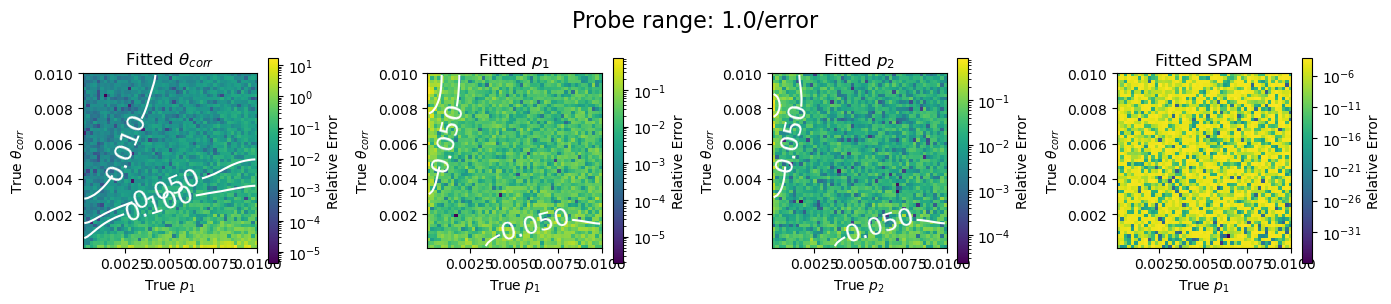

In [20]:
""" Look at the relative error in the fitted parameters as a function of the
true parameters, for a fixed number of shots and sequence lengths. This is to
understand how the probe range (max sequence length), number of points, and number of samples affects the accuracy of the
fit across different error regimes. """

err_model = SO3Model() # This is the model used in the paper.
n_shots = 10**5 # Total samples i.e. num_shots * num_sequences
e_min = 0.0001
e_max = 0.01
e_step = 0.0002
e_arr = np.arange(e_min, e_max + e_step, e_step)

m_min = 1 # Minimum sequence length
m_points = 5 # Number of sequence lengths to use in the fit, spaced logarithmically between m_min and m_max
probe_depth = 1.0 # Maximum sequence length is probe_depth/max(e_corr, p1)

e_corr_matrix = np.zeros((len(e_arr), len(e_arr)))
p1_matrix = np.zeros_like(e_corr_matrix)
p2_matrix = np.zeros_like(e_corr_matrix)
spam_matrix = np.zeros_like(e_corr_matrix)

spam_err = 0.0 # Don't consider SPAM here, but include it in the fit to see if this biases the results
for i, e_corr in enumerate(e_arr):
    for j, p1 in enumerate(e_arr):
        p2 = p1 # Set symmetric single-qubit errors for simplicity
        m_max = probe_depth/max(e_corr, p1)
        ms = np.logspace(np.log10(m_min), np.log10(m_max), m_points, dtype=int)
        e_corr_fit, p1_fit, p2_fit, spam_fit = test_fit(e_corr, p1, p2, spam_err, ms, n_shots)
        e_corr_matrix[i,j] = get_relative_error(e_corr, e_corr_fit)
        p1_matrix[i,j] = get_relative_error(p1, p1_fit)
        p2_matrix[i,j] = get_relative_error(p2, p2_fit)
        spam_matrix[i,j] = spam_fit

fig, ax = plt.subplots(1, 4, figsize=(14, 3))
title = f"Probe range: {probe_depth}/error"
plt.suptitle(title, fontsize=16)
plot_matrix(ax[0], e_corr_matrix, "Fitted $\\theta_{corr}$", "True $p_1$", "True $\\theta_{corr}$")
plot_matrix(ax[1], p1_matrix, "Fitted $p_1$", "True $p_1$", "True $\\theta_{corr}$")
plot_matrix(ax[2], p2_matrix, "Fitted $p_2$", "True $p_2$", "True $\\theta_{corr}$")
plot_matrix(ax[3], spam_matrix, "Fitted SPAM", "True $p_1$", "True $\\theta_{corr}$")

plt.tight_layout()
plt.show()

<Figure size 2400x2400 with 0 Axes>

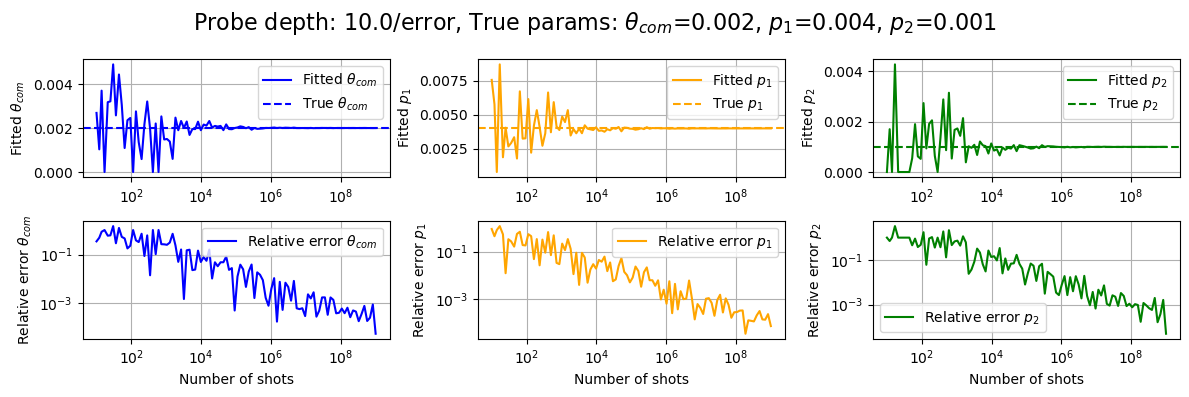

In [ ]:
def scan_num_shots(e_corr, p1,p2, spam, m_min, m_points, probe_depth, min_shots, max_shots):
    """ sit with fixed params and scan number of shots"""
    m_max = probe_depth/min(e_corr, p1, p2)
    ms = np.logspace(np.log10(m_min), np.log10(m_max), m_points, dtype=int)
    shots_arr = np.logspace(np.log10(min_shots), np.log10(max_shots), 100, dtype=int)
    e_fit_arr = []
    p1_fit_arr = []
    p2_fit_arr = []
    for n_shots in shots_arr:
        e_corr_fit, p1_fit, p2_fit, spam_fit = test_fit(e_corr, p1, p2, spam, ms, n_shots)
        e_fit_arr.append(e_corr_fit)
        p1_fit_arr.append(p1_fit)
        p2_fit_arr.append(p2_fit)
    plt.figure(figsize=(24, 24))
    fig, ax = plt.subplots(2, 3, figsize=(12, 4))
    ax[0,0].plot(shots_arr, e_fit_arr, label="Fitted $\\theta_{corr}$", color="blue")
    ax[0,1].plot(shots_arr, p1_fit_arr, label="Fitted $p_1$", color="orange")
    ax[0,2].plot(shots_arr, p2_fit_arr, label="Fitted $p_2$", color="green")
    # plot true values
    ax[0,0].axhline(e_corr, label="True $\\theta_{corr}$", color="blue", linestyle="--")
    ax[0,1].axhline(p1, label="True $p_1$", color="orange", linestyle="--")
    ax[0,2].axhline(p2, label="True $p_2$", color="green", linestyle="--")

    # plot relative error
    ax[1,0].plot(shots_arr, np.abs(np.array(e_fit_arr)-e_corr)/e_corr, label="Relative error $\\theta_{corr}$", color="blue")
    ax[1,1].plot(shots_arr, np.abs(np.array(p1_fit_arr)-p1)/p1, label="Relative error $p_1$", color="orange")
    ax[1,2].plot(shots_arr, np.abs(np.array(p2_fit_arr)-p2)/p2, label="Relative error $p_2$", color="green")   

    # axis y labels
    ax[0,0].set_ylabel("Fitted $\\theta_{corr}$")
    ax[0,1].set_ylabel("Fitted $p_1$")
    ax[0,2].set_ylabel("Fitted $p_2$")
    ax[1,0].set_ylabel("Relative error $\\theta_{corr}$")
    ax[1,1].set_ylabel("Relative error $p_1$")
    ax[1,2].set_ylabel("Relative error $p_2$")
    for a in ax.flatten():
        a.set_xscale("log")
        a.legend()
        a.grid()
    for a in ax[1,:]:
        a.set_xlabel("Number of shots")
        a.set_yscale("log")

    # super title, give initial params and probe depth
    title = f"Probe depth: {probe_depth}/error, True params: $\\theta_{{corr}}$={e_corr}, $p_1$={p1}, $p_2$={p2}"
    plt.suptitle(title, fontsize=16)
    plt.tight_layout()


e_corr = 0.002
p1 = 0.004
p2 = 0.001
m_min = 1
m_points = 11
probe_depth = 10.0
min_shots = 10**1
max_shots = 10**9
spam = 0.0

scan_num_shots(e_corr, p1, p2, spam, m_min, m_points, probe_depth, min_shots, max_shots)

<Figure size 2400x2400 with 0 Axes>

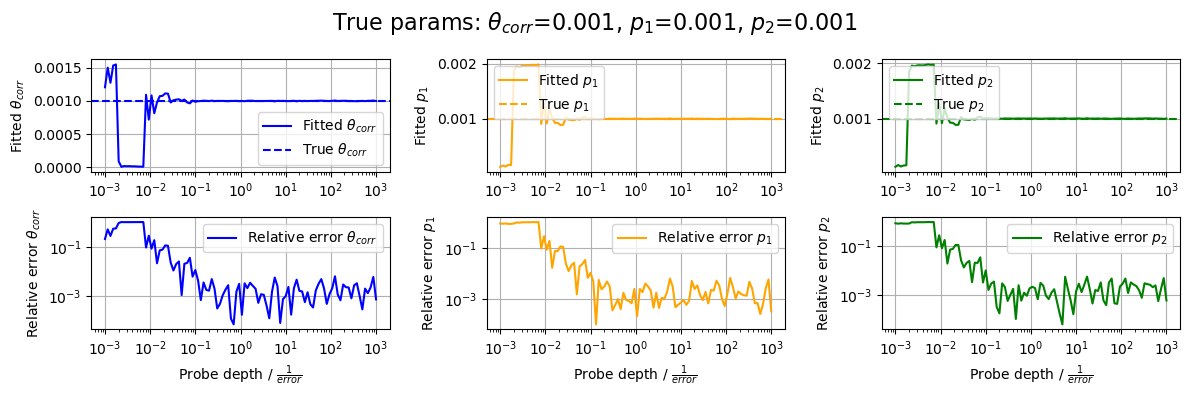

In [39]:
def scan_probe_depth(e_corr, p1,p2, spam, m_min, m_points, shots, min_probe_depth, max_probe_depth):
    """ sit with fixed params and scan number of probe depths"""
    probe_depth_arr = np.logspace(np.log10(min_probe_depth), np.log10(max_probe_depth), 100)
    e_fit_arr = []
    p1_fit_arr = []
    p2_fit_arr = []
    for probe_depth in probe_depth_arr:
        m_max = probe_depth/max(e_corr, p1, p2)
        ms = np.logspace(np.log10(m_min), np.log10(m_max), m_points, dtype=int)
        e_corr_fit, p1_fit, p2_fit, spam_fit = test_fit(e_corr, p1, p2, spam_err, ms, shots)
        e_fit_arr.append(e_corr_fit)
        p1_fit_arr.append(p1_fit)
        p2_fit_arr.append(p2_fit)
    plt.figure(figsize=(24, 24))
    fig, ax = plt.subplots(2, 3, figsize=(12, 4))
    ax[0,0].plot(probe_depth_arr, e_fit_arr, label="Fitted $\\theta_{corr}$", color="blue")
    ax[0,1].plot(probe_depth_arr, p1_fit_arr, label="Fitted $p_1$", color="orange")
    ax[0,2].plot(probe_depth_arr, p2_fit_arr, label="Fitted $p_2$", color="green")
    # plot true values
    ax[0,0].axhline(e_corr, label="True $\\theta_{corr}$", color="blue", linestyle="--")
    ax[0,1].axhline(p1, label="True $p_1$", color="orange", linestyle="--")
    ax[0,2].axhline(p2, label="True $p_2$", color="green", linestyle="--")

    # plot relative error
    ax[1,0].plot(probe_depth_arr, np.abs(np.array(e_fit_arr)-e_corr)/e_corr, label="Relative error $\\theta_{corr}$", color="blue")
    ax[1,1].plot(probe_depth_arr, np.abs(np.array(p1_fit_arr)-p1)/p1, label="Relative error $p_1$", color="orange")
    ax[1,2].plot(probe_depth_arr, np.abs(np.array(p2_fit_arr)-p2)/p2, label="Relative error $p_2$", color="green")   

    # axis y labels
    ax[0,0].set_ylabel("Fitted $\\theta_{corr}$")
    ax[0,1].set_ylabel("Fitted $p_1$")
    ax[0,2].set_ylabel("Fitted $p_2$")
    ax[1,0].set_ylabel("Relative error $\\theta_{corr}$")
    ax[1,1].set_ylabel("Relative error $p_1$")
    ax[1,2].set_ylabel("Relative error $p_2$")
    for a in ax.flatten():
        a.set_xscale("log")
        a.legend()
        a.grid()
    for a in ax[1,:]:
        a.set_xlabel("Probe depth / $\\frac{1}{error}$")
        a.set_yscale("log")

    title = f"True params: $\\theta_{{corr}}$={e_corr}, $p_1$={p1}, $p_2$={p2}"
    plt.suptitle(title, fontsize=16)
    plt.tight_layout()


e_corr = 0.001
p1 = 0.001
p2 = 0.001
spam = 0.0
m_min = 1
m_points = 11
min_probe_depth = 0.001
max_probe_depth = 1000
shots = 10**7
scan_probe_depth(e_corr, p1, p2, spam, m_min, m_points, shots, min_probe_depth, max_probe_depth)